# IIR Filtering

这是陈硕写的《数字信号处理入门实验》的第二章第3个实验，介绍 IIR 数字滤波器的设计与使用。
最新版网址： https://github.com/chenshuo/notes/tree/master/notebooks/dsp

预览运行结果： http://chenshuo.github.io/labs/lab/index.html?path=dsp/2c-iir-filtering.ipynb

本章内容的视频讲解在
* [IIR 滤波、陷波](https://www.youtube.com/watch?v=Bxf29Vc45Sg)  国内：https://www.bilibili.com/video/BV1pe4y1X7J5

如果在 Jupyter-lite 下运行，需要安装：

In [ ]:
%pip install -q ipywidgets

照例先引入 NumPy、SciPy.signal、Matplotlib 等必要的库，再定义两个常用的绘图函数。

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

from ipywidgets import interact

np.set_printoptions(suppress=True)

In [4]:
def draw_pzmap(dlti):
  plt.plot(np.real(dlti.zeros), np.imag(dlti.zeros), 'o', mfc='none')
  plt.plot(np.real(dlti.poles), np.imag(dlti.poles), 'x')
  w = np.linspace(0, 2*np.pi)
  plt.plot(np.cos(w), np.sin(w), 'y--')
  limits = plt.axis("equal")
  plt.grid()

def draw_resp_stem(x, y):
  plt.stem(x)
  (markerline, _, _) = plt.stem(y, linefmt='r', markerfmt='ro')
  markerline.set_markerfacecolor('none')

$H(\omega) = H(z)|_{z=e^{j\omega}}$, $0 \le \omega \le \pi$

$H(z) =  \dfrac{b_0 + b_1z^{-1}+b_2z^{-2}+\cdots+b_Lz^{-L}}{1+a_1z^{-1}+a_2z^{-2}+\cdots+a_Mz^{-M}}$


## DC blocker

Julius O. Smith, Introduction to Digital Filters with Audio Applications, http://ccrma.stanford.edu/~jos/filters/

Appendix B.3 https://ccrma.stanford.edu/~jos/filters/DC_Blocker.html

$y[n] = x[n]-x[n-1]+Ry[n-1]$

$H(z)=\dfrac{1-z^{-1}}{1-Rz^{-1}}$

It's a differentiator with exponential moving average.

Zeros: [1.]
Poles: [0.9]


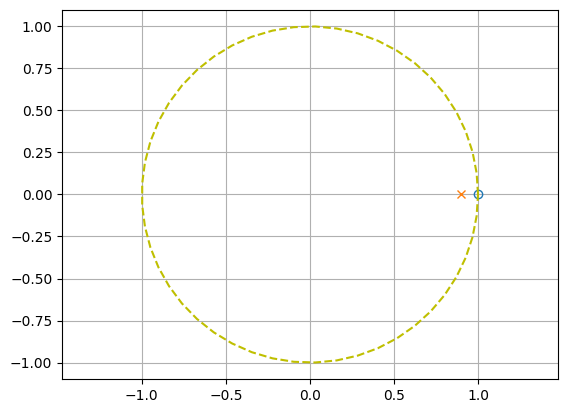

In [12]:
R = 0.9
b = [1, -1]
a = [1, -R]
dlti = signal.dlti(b, a)
zeros = dlti.zeros
print('Zeros:', zeros)
print('Poles:', dlti.poles)
draw_pzmap(dlti)

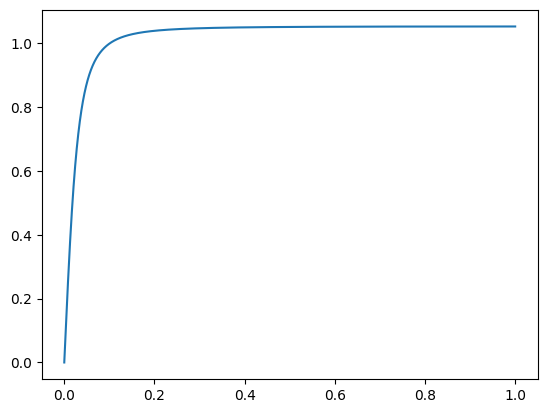

In [13]:
w, mag = dlti.freqresp()
plt.plot(w/np.pi, np.abs(mag))

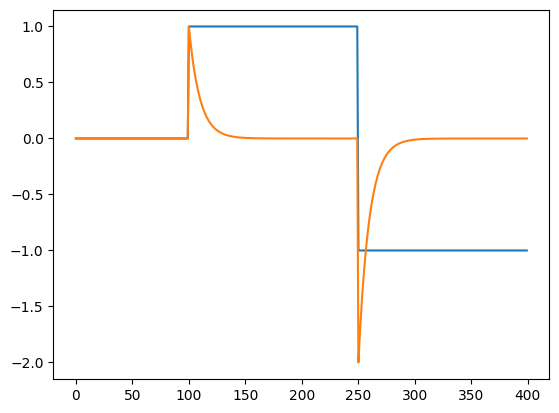

In [14]:
dc = np.concatenate([np.zeros(100), np.ones(150), -1 * np.ones(150)])
y = signal.lfilter(b, a, dc)
plt.plot(dc)
plt.plot(y)

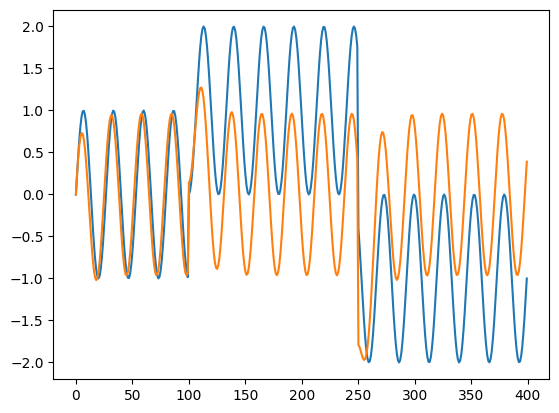

In [15]:
t = np.linspace(0, 1, 400) * 2 *np.pi * 15
x = np.sin(t) + dc

y = signal.lfilter(b, a, x)
plt.plot(x)
plt.plot(y)

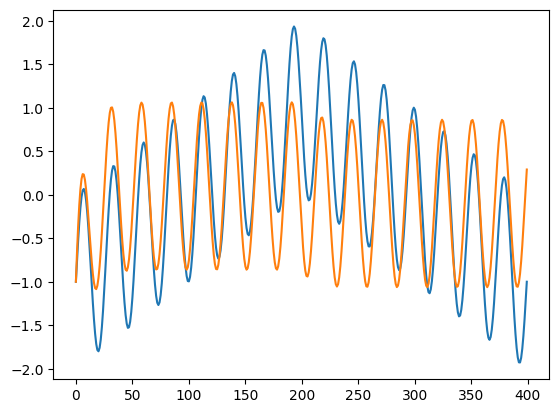

In [16]:
t = np.linspace(0, 1, 400) * 2 *np.pi
x = np.sin(t * 15)
triangle = signal.sawtooth(t, 0.5)
x = x + triangle

y = signal.lfilter(b, a, x)
plt.plot(x)
plt.plot(y)

In [17]:
@interact(R=(0, 0.99, 0.01))
def blocker(R=0.88):
  b = [1, -1]
  a = [1, -R]
  dlti = signal.dlti(b, a)
  plt.figure(figsize=(15,5))
  plt.subplot(121)
  draw_pzmap(dlti)
  w, mag = dlti.freqresp()
  plt.subplot(122)
  plt.plot(w/np.pi, np.abs(mag))

interactive(children=(FloatSlider(value=0.88, description='R', max=0.99, step=0.01), Output()), _dom_classes=(…

## Notch filter

https://www.mathworks.com/help/signal/ug/remove-the-60-hz-hum-from-a-signal.html

Sophocles J. Orfanidis. _Introduction to Signal Processing, 1996._ 

§11.3 Second-Order Peaking and Notching Filters

https://www.ece.rutgers.edu/~orfanidi/intro2sp/

In [7]:
fs=1000
b, a = signal.iirnotch(60, Q=30, fs=fs)
d = signal.dlti(b, a)
print('b=', np.round(b, 5))
print('a=', np.round(a, 5))

b= [ 0.99376 -1.84794  0.99376]
a= [ 1.      -1.84794  0.98751]


$y[n] = 0.99376\,x[n] - 1.84794\,x[n-1] + 0.99376\,x[n-2] + 1.84794\,y[n-1] - 0.98751\,y[n-2]$

$b = 0.99376$, $\omega_0 = \dfrac{60\cdot 2\pi}{1000}$

$H(z) = b\dfrac{1-2\cos \omega_0 z^{-1}+z^{-2}}{1-2b\cos \omega_0 z^{-1}+(2b-1)z^{-2}}$

In [14]:
gain = b[0]

omega0 = 60*2*np.pi/1000
print('2 * b * cos(w0) = %.5f' % (2*np.cos(omega0)*gain))
print('2b - 1 = %.5f' % (2*gain - 1))

2 * b * cos(w0) = 1.84794
2b - 1 = 0.98751


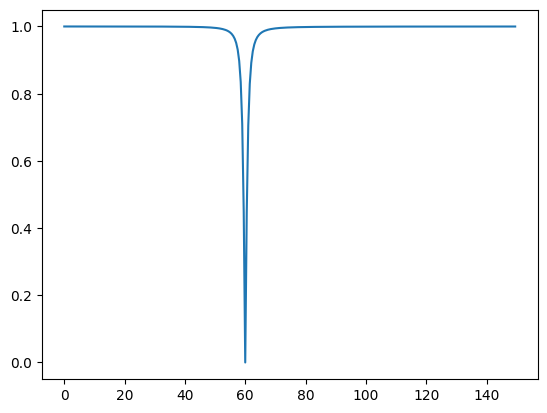

In [19]:
w, amp = d.freqresp(n=1000)
w=w[0:300]
amp=amp[0:300]
plt.plot(w/(2*np.pi)*fs, np.abs(amp))

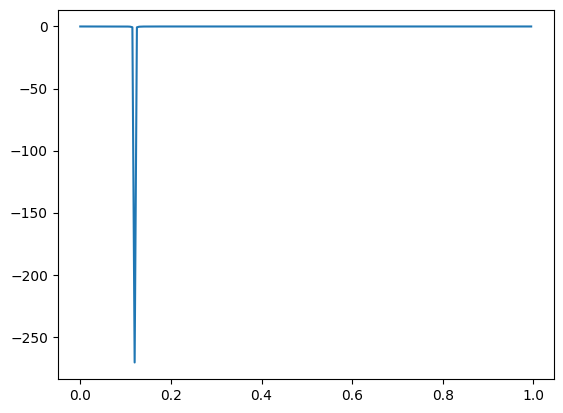

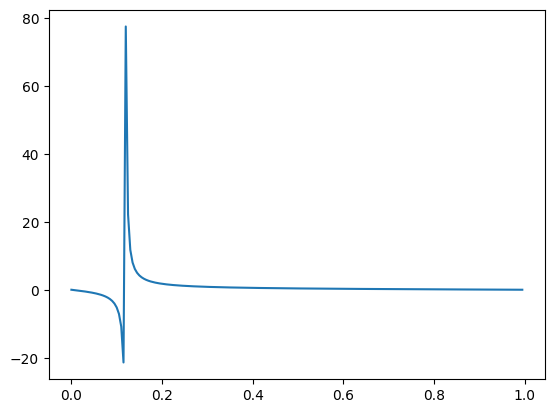

In [20]:
w, mag, phase = d.bode(n=200)
plt.plot(w/np.pi, mag)
plt.figure()
plt.plot(w/np.pi, phase)

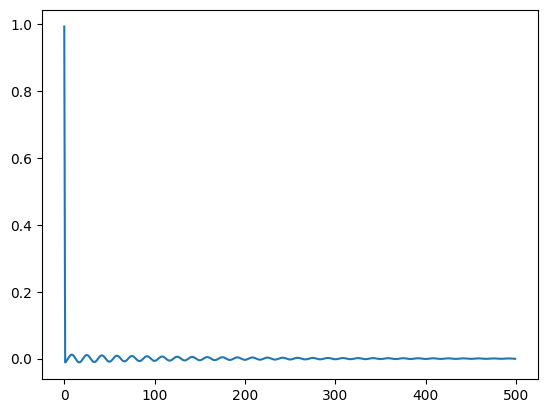

In [21]:
t, y = d.impulse(n=500)
plt.plot(t, y[0])

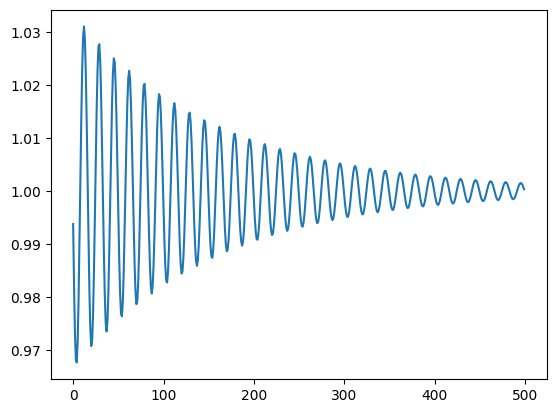

In [22]:
t, y = d.step(n=500)
plt.plot(t, y[0])

zeros 1.00000 60.000Hz
poles 0.99374 59.992Hz


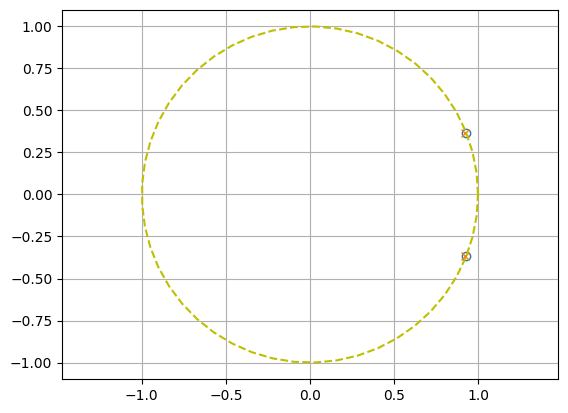

In [23]:
print('zeros %.5f %.3fHz' % (np.abs(d.zeros[0]), np.angle(d.zeros[0]) * fs / (2*np.pi)))
print('poles %.5f %.3fHz' % (np.abs(d.poles[0]), np.angle(d.poles[0]) * fs / (2*np.pi)))
draw_pzmap(d)

### EEG

脑电信号

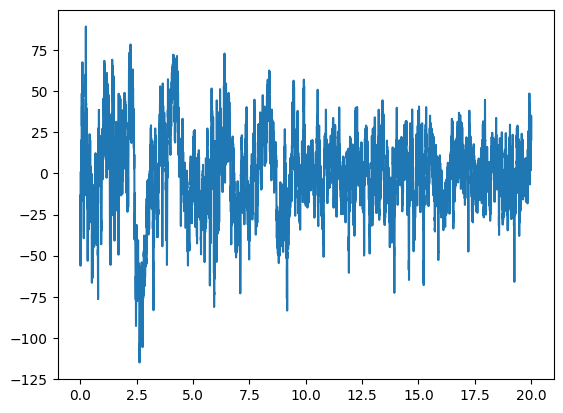

In [6]:
eeg = np.loadtxt('data/eeg.txt').T
fs = 500
x = eeg[0]
t = np.arange(len(x)) / fs
_ = plt.plot(t, x)

可以看出在 150Hz 和 200Hz 处有尖峰

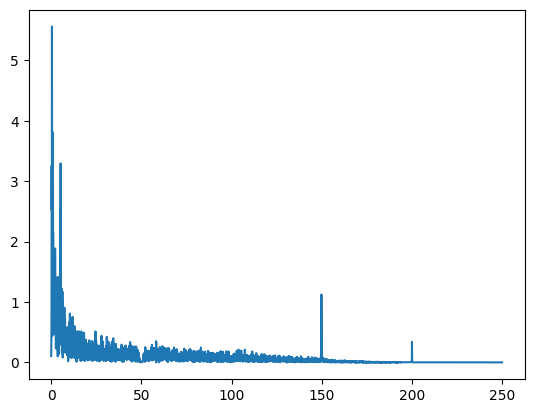

In [26]:
fft = np.fft.rfft(x) / len(x)
freq = np.arange(len(fft)) / len(fft) * fs / 2
plt.plot(freq, np.abs(fft))

仔细观察 40Hz ~ 60Hz 附近的频谱，发现很可能这个信号样本已经把 50Hz 的交流电干扰过滤掉了。

(0.0, 0.5)

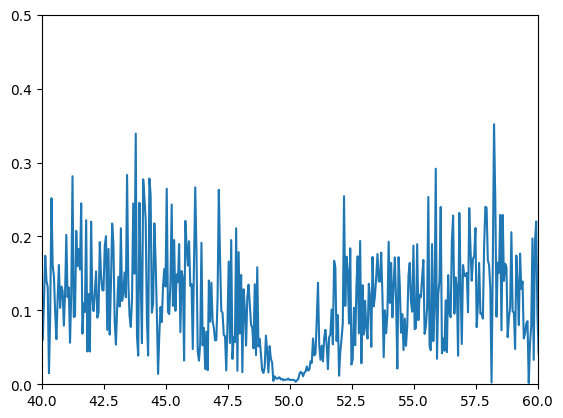

In [27]:
plt.plot(freq, np.abs(fft))
plt.xlim(40, 60)
plt.ylim(0, 0.5)

接下来我们的任务是设法去除 150Hz 的市电三次谐波。

(140.0, 160.0)

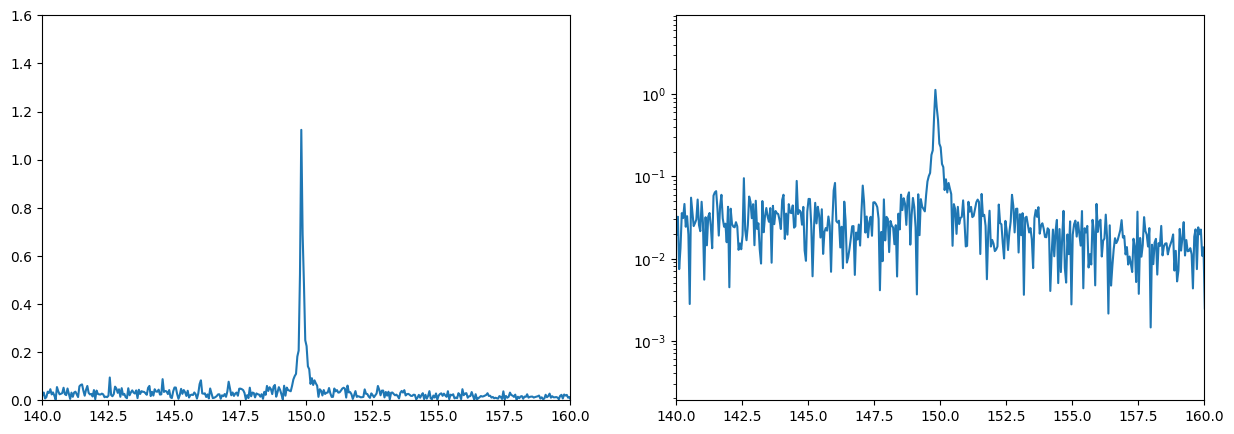

In [28]:
plt.figure(figsize=(15,5))
plt.subplot(121)
plt.plot(freq, np.abs(fft))
plt.xlim(140, 160)
plt.ylim(0, 1.6)
plt.subplot(122)
plt.semilogy(freq, np.abs(fft))
plt.xlim(140, 160)

产生一个 IIR 陷波器。

b= [0.9815 0.6066 0.9815]
a= [1.      0.6066  0.96299]
zeros 1.00000 150.000Hz
poles 0.98132 150.005Hz


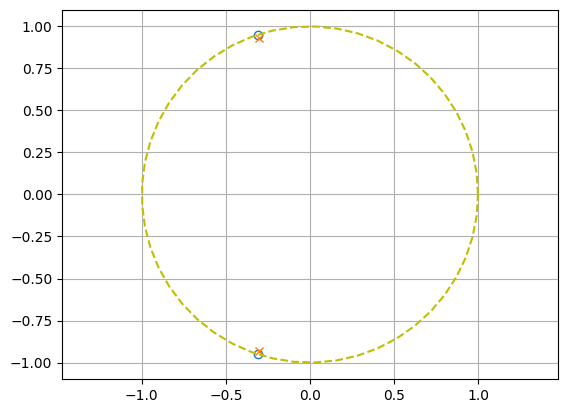

In [8]:
b, a = signal.iirnotch(150, Q=50, fs=fs)
d = signal.dlti(b, a)
print('b=', np.round(b, 5))
print('a=', np.round(a, 5))
draw_pzmap(d)
print('zeros %.5f %.3fHz' % (np.abs(d.zeros[0]), np.angle(d.zeros[0]) * fs / (2*np.pi)))
print('poles %.5f %.3fHz' % (np.abs(d.poles[0]), np.angle(d.poles[0]) * fs / (2*np.pi)))

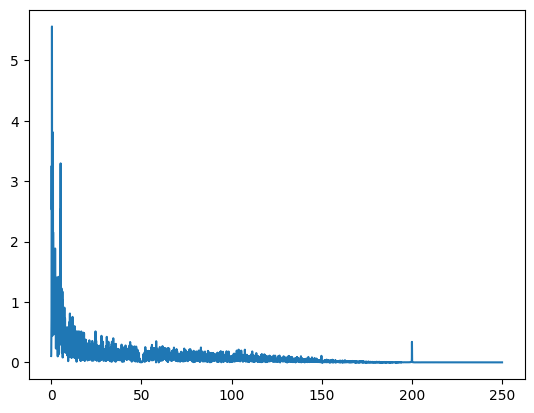

In [30]:
y = signal.lfilter(b, a, x)
ffty = np.fft.rfft(y) / len(y)
freq = np.arange(len(ffty)) / len(ffty) * fs / 2
plt.plot(freq, np.abs(ffty))

(140.0, 160.0)

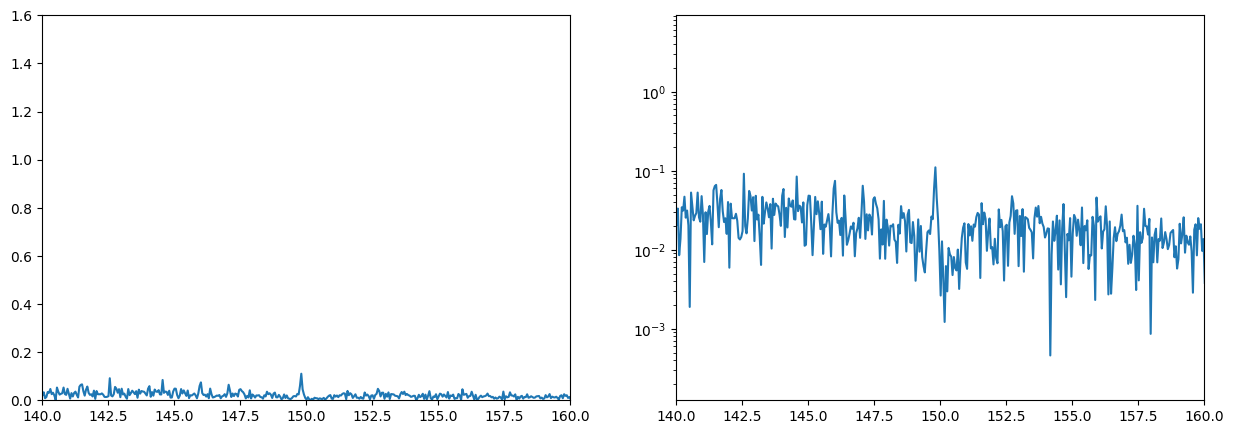

In [31]:
plt.figure(figsize=(15,5))
plt.subplot(121)
plt.plot(freq, np.abs(ffty))
plt.xlim(140, 160)
plt.ylim(0, 1.6)
plt.subplot(122)
plt.semilogy(freq, np.abs(ffty))
plt.xlim(140, 160)

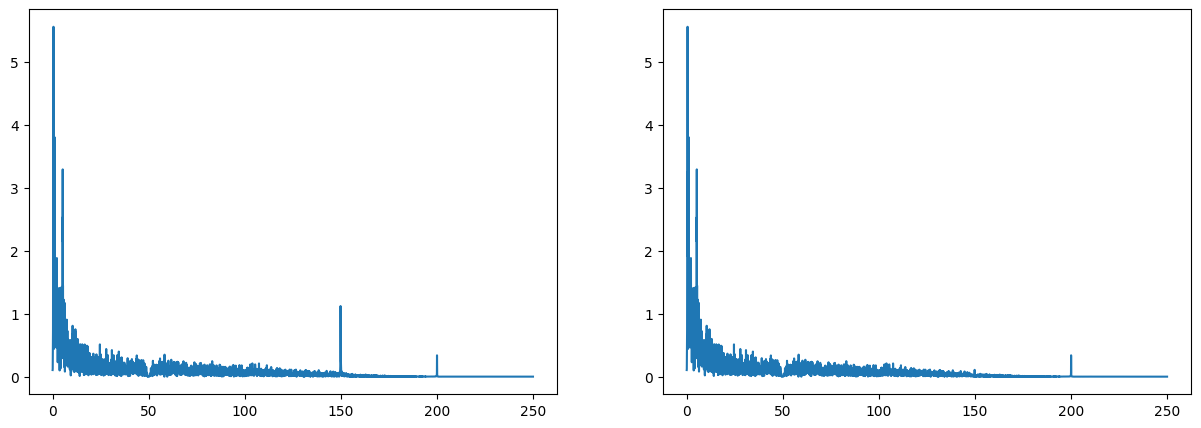

In [32]:
plt.figure(figsize=(15,5))
plt.subplot(121)
plt.plot(freq, np.abs(fft))
plt.subplot(122)
plt.plot(freq, np.abs(ffty))

(140.0, 160.0)

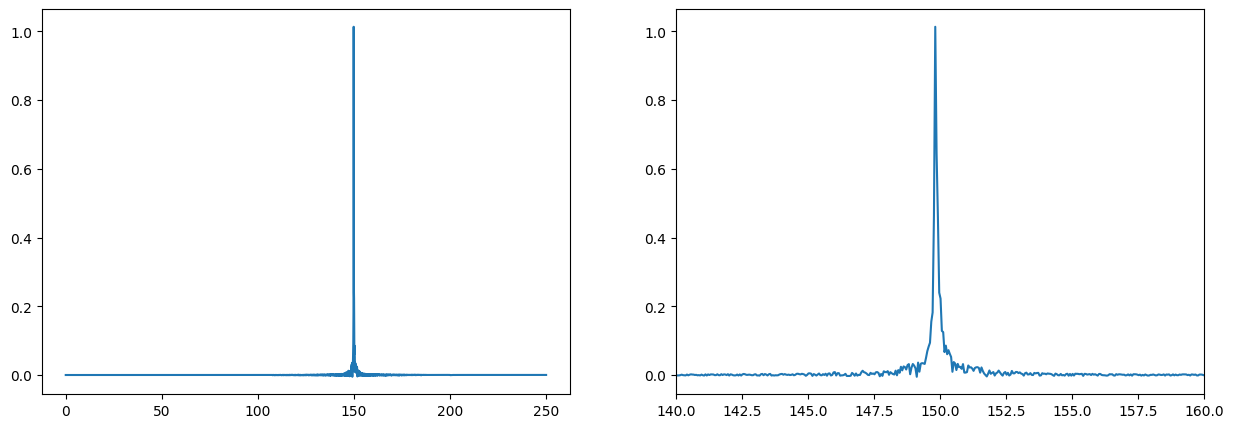

In [33]:
plt.figure(figsize=(15,5))
plt.subplot(121)
plt.plot(freq, np.abs(fft)-np.abs(ffty))
plt.subplot(122)
plt.plot(freq, np.abs(fft)-np.abs(ffty))
plt.xlim(140, 160)

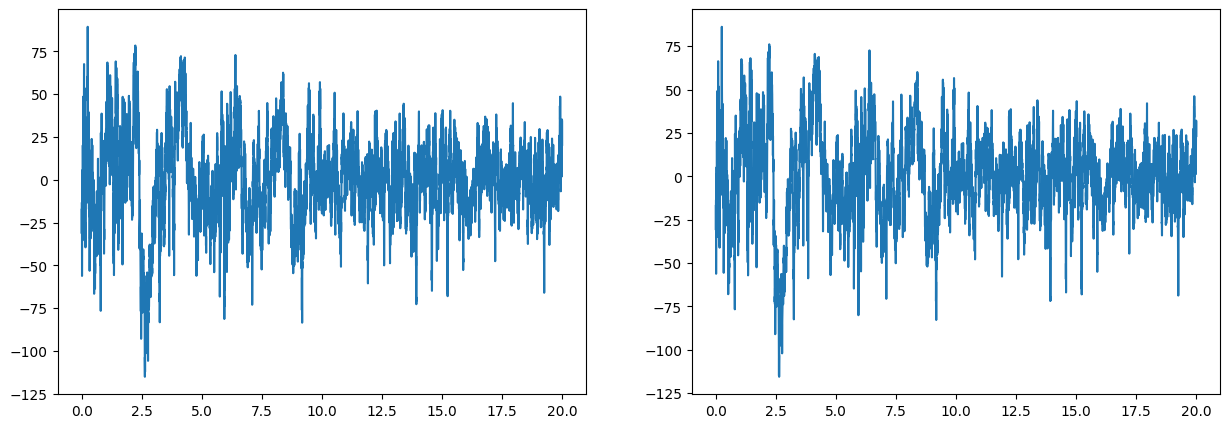

In [34]:
plt.figure(figsize=(15,5))
plt.subplot(121)
plt.plot(t, x)
plt.subplot(122)
plt.plot(t, y)

(1.0, 1.1)

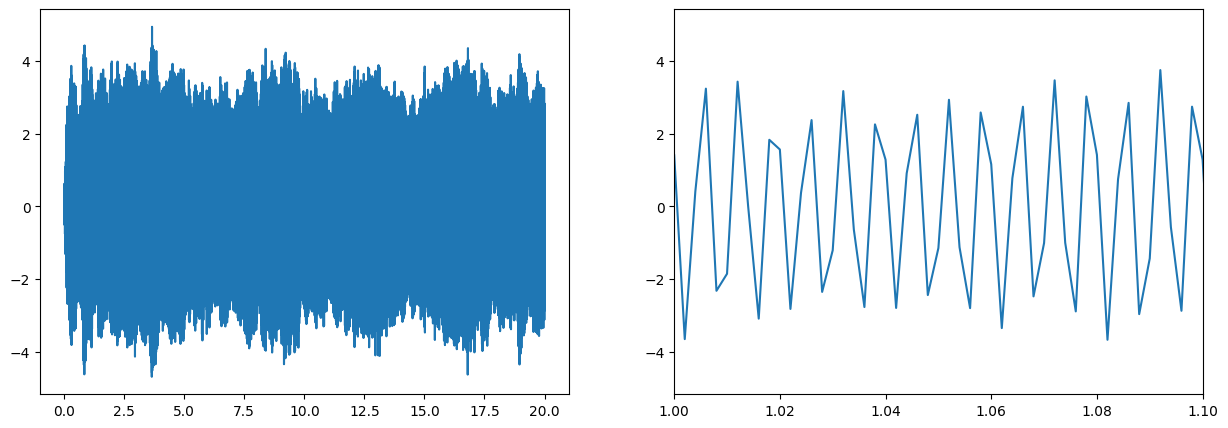

In [35]:
diff = y-x
plt.figure(figsize=(15,5))
plt.subplot(121)
plt.plot(t, diff)
plt.subplot(122)
plt.plot(t, diff)
plt.xlim(1, 1.1)

(140.0, 160.0)

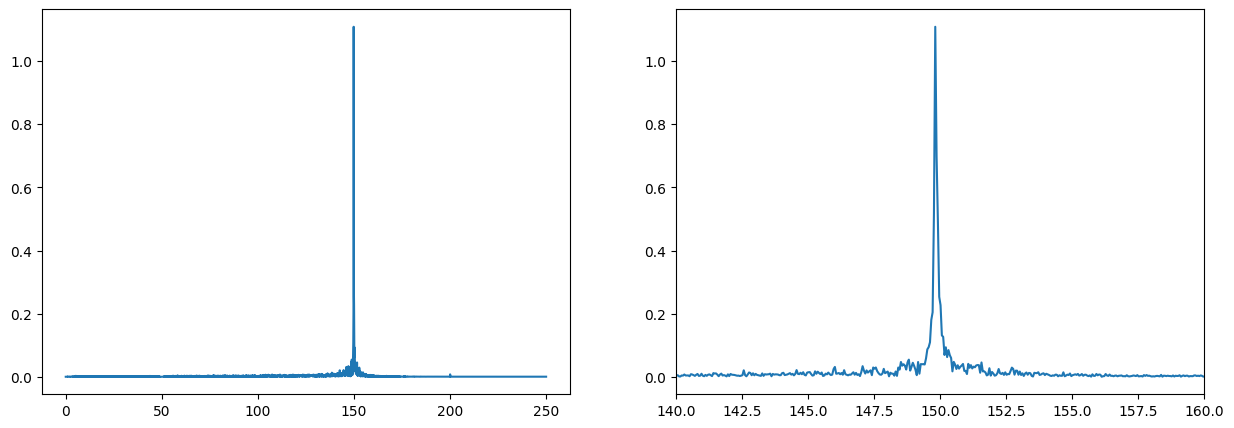

In [36]:
fftd = np.fft.rfft(diff) / len(diff)
plt.figure(figsize=(15,5))
plt.subplot(121)
plt.plot(freq, np.abs(fftd))
plt.subplot(122)
plt.plot(freq, np.abs(fftd))
plt.xlim(140, 160)

FFT(y - x) = FFT(y) - FFT(x)

**练习**： Remove 15.625 kHz noise from CD recordings?


**THD**

https://www.youtube.com/watch?v=Zvireu2SGZM&t=831s